# Compute the frequency spectrum of a timeseries

This notebook demonstrates how to compute the discrete Fourier Transform (FFT) of a timeseries using `temporal.fft`. The time dimension is detected automatically and the returned frequency coordinate is expressed in Hz (cycles per second). We use a short hourly 2m temperature timeseries, which has a strong diurnal (24-hour) cycle.

In [1]:
import numpy as np

from earthkit import data as ekd
from earthkit import transforms as ekt

# Hourly 2m temperature timeseries for two locations (72 hourly steps, 3 days)
ds = ekd.from_source("sample", "era5-timeseries-multiple.nc").to_xarray()
da = ds["t2m"].sel(location="Reading")

da

<xarray.DataArray 't2m' (valid_time: 72)> Size: 288B
[72 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 576B 2026-05-23 ... 2026-05-25T23...
    location    <U9 36B 'Reading'
    latitude    float64 8B ...
    longitude   float64 8B ...
    utc_offset  timedelta64[s] 8B ...
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

## Compute the FFT

`temporal.fft` detects the time dimension (`valid_time`) automatically and returns a complex-valued result indexed by a `frequency` dimension. The frequency coordinate is derived from the hourly sampling and expressed in Hz.

In [2]:
spectrum = ekt.temporal.fft(da)

spectrum

<xarray.DataArray 't2m' (frequency: 72)> Size: 576B
array([ 2.1254309e+04+0.0000000e+00j,  3.6181873e+01+8.3899078e+01j,
        1.8603952e+01+3.0636444e+01j, -1.9632404e+02+1.7992714e+02j,
        1.4326304e-01-1.8276188e+01j,  2.1387093e-02-3.5564790e+00j,
        1.5857482e+00+7.8525548e+00j, -8.0988111e+00-1.5550503e-01j,
       -9.4715452e+00+3.8258581e+00j,  1.0177716e+01-1.7595097e+01j,
        3.9469767e-01+5.0195365e+00j, -6.0290465e+00+3.9161768e+00j,
        4.1107635e+00-3.0908978e+00j, -1.7498523e+00+1.9973781e+00j,
       -1.5209463e+00+3.6424193e-01j, -4.9151093e-01+2.5865140e+00j,
       -3.2336328e+00+1.4347422e+00j, -8.6006445e-01+6.3981169e-01j,
       -4.4917297e+00+5.6923523e+00j, -6.9665194e-01+1.0354474e+00j,
       -2.8036752e+00+8.2415718e-01j, -2.4032340e+00+1.9318168e+00j,
       -1.5208218e+00+3.7614647e-01j, -3.4489987e+00+6.1524749e-01j,
       -2.9255829e+00-4.9863592e-01j, -2.0512412e+00+1.5625035e+00j,
       -2.7773783e+00+9.0367144e-01j, -1.7438781e+00+6.6997933e-01j,
       -2.3840063e+00+1.4095925e+00j, -1.4071045e+00+4.2337486e-01j,
       -2.3490539e+00+3.8001978e-01j, -1.9792778e+00+1.1325877e+00j,
       -1.9649117e+00+8.0021866e-02j, -2.6341197e+00+1.8611387e+00j,
       -1.6150200e+00+3.7647539e-01j, -2.0705647e+00+2.7284950e-01j,
       -1.4873657e+00+0.0000000e+00j, -2.0705647e+00-2.7284950e-01j,
       -1.6150200e+00-3.7647539e-01j, -2.6341197e+00-1.8611387e+00j,
       -1.9649117e+00-8.0021866e-02j, -1.9792778e+00-1.1325877e+00j,
       -2.3490539e+00-3.8001978e-01j, -1.4071045e+00-4.2337486e-01j,
       -2.3840063e+00-1.4095925e+00j, -1.7438781e+00-6.6997933e-01j,
       -2.7773783e+00-9.0367144e-01j, -2.0512412e+00-1.5625035e+00j,
       -2.9255829e+00+4.9863592e-01j, -3.4489987e+00-6.1524749e-01j,
       -1.5208218e+00-3.7614647e-01j, -2.4032340e+00-1.9318168e+00j,
       -2.8036752e+00-8.2415718e-01j, -6.9665194e-01-1.0354474e+00j,
       -4.4917297e+00-5.6923523e+00j, -8.6006445e-01-6.3981169e-01j,
       -3.2336328e+00-1.4347422e+00j, -4.9151093e-01-2.5865140e+00j,
       -1.5209463e+00-3.6424193e-01j, -1.7498523e+00-1.9973781e+00j,
        4.1107635e+00+3.0908978e+00j, -6.0290465e+00-3.9161768e+00j,
        3.9469767e-01-5.0195365e+00j,  1.0177716e+01+1.7595097e+01j,
       -9.4715452e+00-3.8258581e+00j, -8.0988111e+00+1.5550503e-01j,
        1.5857482e+00-7.8525548e+00j,  2.1387093e-02+3.5564790e+00j,
        1.4326304e-01+1.8276188e+01j, -1.9632404e+02-1.7992714e+02j,
        1.8603952e+01-3.0636444e+01j,  3.6181873e+01-8.3899078e+01j],
      dtype=complex64)
Coordinates:
  * frequency   (frequency) float64 576B 0.0 3.858e-06 ... -7.716e-06 -3.858e-06
    location    <U9 36B 'Reading'
    latitude    float64 8B ...
    longitude   float64 8B ...
    utc_offset  timedelta64[s] 8B ...
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K

## Identify the dominant period

We keep the positive frequencies, compute the amplitude of each frequency component, and convert the frequency (Hz) to a period in hours. The largest amplitude corresponds to the dominant cycle in the data.

In [3]:
# Keep positive frequencies only (drop the zero-frequency/mean component)
positive = spectrum.where(spectrum["frequency"] > 0, drop=True)
amplitude = np.abs(positive)

# Convert frequency in Hz to a period in hours
period_hours = 1.0 / (positive["frequency"] * 3600.0)
amplitude = amplitude.assign_coords(period_hours=("frequency", period_hours.data))

dominant_period = float(amplitude["period_hours"][amplitude.argmax("frequency")].item())
print(f"Dominant period: {dominant_period:.1f} hours")

Dominant period: 24.0 hours


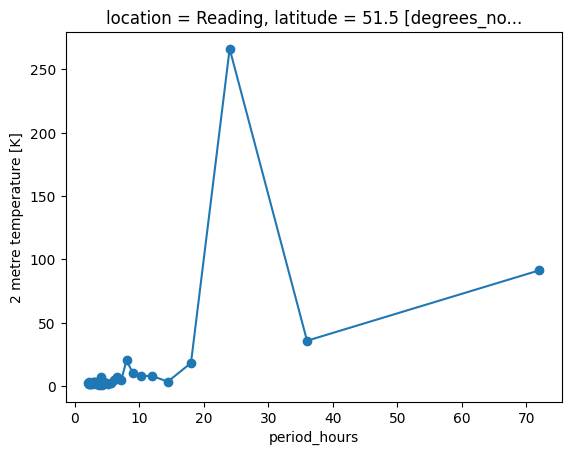

In [4]:
amplitude.plot.line(x="period_hours", marker="o")